In [4]:
import wrds
import pandas as pd
db = wrds.Connection()

Enter your WRDS username [rajath]: rajaths25
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [126]:
from scipy import stats
import matplotlib.pyplot as plt

In [127]:
# print(db.list_tables(library='crsp'))

We select all the columns specific to the compustat fundamentals per quarter dataset.
We include only the records within the past 10 years from today. Avoid any missing columns and also order by company id and date.
Also, we now filter by market value.


In [128]:
query = """
select gvkey, conm, datadate, fyearq, fqtr, revtq, niq, oancfy, mkvaltq
from comp.fundq
where datadate >= current_date - interval '10 years'
and revtq is not null 
and niq is not null 
and mkvaltq is not null 
and oancfy is not null 
and mkvaltq >= 5000
order by gvkey, datadate
"""

fundq = db.raw_sql(query)
print(fundq.head())

    gvkey                         conm    datadate  fyearq  fqtr    revtq  \
0  001045  AMERICAN AIRLINES GROUP INC  2015-09-30    2015     3  10706.0   
1  001045  AMERICAN AIRLINES GROUP INC  2015-12-31    2015     4   9630.0   
2  001045  AMERICAN AIRLINES GROUP INC  2016-03-31    2016     1   9435.0   
3  001045  AMERICAN AIRLINES GROUP INC  2016-06-30    2016     2  10363.0   
4  001045  AMERICAN AIRLINES GROUP INC  2016-09-30    2016     3  10593.0   

      niq  oancfy     mkvaltq  
0  1693.0  6021.0  24855.3936  
1  3281.0  6249.0  26452.7417  
2   700.0  2620.0  24017.8346  
3   950.0  4833.0  15206.4617  
4   737.0  5897.0  19006.4842  


In [129]:
fundq.head()

,gvkey,conm,datadate,fyearq,fqtr,revtq,niq,oancfy,mkvaltq
0,001045,AMERICAN AIRLINES GROUP INC,2015-09-30,2015,3,10706.0,1693.0,6021.0,24855.3936
1,001045,AMERICAN AIRLINES GROUP INC,2015-12-31,2015,4,9630.0,3281.0,6249.0,26452.7417
2,001045,AMERICAN AIRLINES GROUP INC,2016-03-31,2016,1,9435.0,700.0,2620.0,24017.8346
3,001045,AMERICAN AIRLINES GROUP INC,2016-06-30,2016,2,10363.0,950.0,4833.0,15206.4617
4,001045,AMERICAN AIRLINES GROUP INC,2016-09-30,2016,3,10593.0,737.0,5897.0,19006.4842


In [130]:
len(fundq)


37589

Lets check the number of companies that we have

In [131]:
fundq['gvkey'].nunique()

1881

Lets calculate yoy quarterly growth

In [132]:
import pandas as pd
import numpy as np

Add positive cashflow filter for 70 percent of the quarters

In [133]:
# 1. Companies with >70% quarters having positive operating cash flow
cashflow_filter = fundq.groupby('gvkey')['oancfy'].apply(lambda x: (x > 0).mean() > 0.7)
print("Cashflow Filter Sample:")
print(cashflow_filter.head())

# 2. Companies with more than 10 years of data
years_count = fundq.groupby('gvkey')['fyearq'].nunique()
years_filter = years_count > 10
print("Years Filter Sample:")
print(years_filter.head())

# remove high valued companies - as we are looking for a combination of both value and momentum
fundq['pe_ratio'] = fundq['mkvaltq'] / (fundq['niq'] * 4)
print(fundq['pe_ratio'].head())
# Replace infinite or negative P/E ratios with NaN for filtering
fundq['pe_ratio'] = fundq['pe_ratio'].replace([np.inf, -np.inf], np.nan)
# check all the 
pe_filter = fundq.groupby('gvkey')['pe_ratio'].apply(lambda x: (x <= 100).mean() > 0.7)
print("P/E Filter Sample:")
print(pe_filter.head())

# 3. Combine both filters
valid_gvkeys = cashflow_filter & years_filter & pe_filter
# valid_gvkeys = cashflow_filter & years_filter
valid_gvkeys = valid_gvkeys[valid_gvkeys].index

# 4. Apply to fundq
fundq = fundq[fundq['gvkey'].isin(valid_gvkeys)]

Cashflow Filter Sample:
gvkey
001045    True
001075    True
001078    True
001161    True
001177    True
Name: oancfy, dtype: bool
Years Filter Sample:
gvkey
001045     True
001075     True
001078     True
001161    False
001177    False
Name: fyearq, dtype: bool
0    3.670318
1    2.015601
2    8.577798
3      4.0017
4    6.447247
Name: pe_ratio, dtype: Float64
P/E Filter Sample:
gvkey
001045    True
001075    True
001078    True
001161    True
001177    True
Name: pe_ratio, dtype: bool


In [134]:
# filtered_df_age = fundq[fundq['gvkey'] == "034418"]
# print(filtered_df_age.groupby('gvkey')['oancfy'].mean())

fundq['gvkey'].nunique()

453

In [135]:
fundq.head()

,gvkey,conm,datadate,fyearq,fqtr,revtq,niq,oancfy,mkvaltq,pe_ratio
0,001045,AMERICAN AIRLINES GROUP INC,2015-09-30,2015,3,10706.0,1693.0,6021.0,24855.3936,3.670318
1,001045,AMERICAN AIRLINES GROUP INC,2015-12-31,2015,4,9630.0,3281.0,6249.0,26452.7417,2.015601
2,001045,AMERICAN AIRLINES GROUP INC,2016-03-31,2016,1,9435.0,700.0,2620.0,24017.8346,8.577798
3,001045,AMERICAN AIRLINES GROUP INC,2016-06-30,2016,2,10363.0,950.0,4833.0,15206.4617,4.0017
4,001045,AMERICAN AIRLINES GROUP INC,2016-09-30,2016,3,10593.0,737.0,5897.0,19006.4842,6.447247


Perform growth computation

In [136]:
# Sort by company, quarter, and date
fundq = fundq.sort_values(['gvkey', 'fqtr', 'datadate'])

# For each company and quarter, lag by 1 row (previous year's same quarter)
fundq['revtq_lag_yoy'] = fundq.groupby(['gvkey', 'fqtr'])['revtq'].shift(1)
fundq['niq_lag_yoy'] = fundq.groupby(['gvkey', 'fqtr'])['niq'].shift(1)

# Calculate YoY percentage growth
fundq['revtq_growth_yoy'] = (fundq['revtq'] - fundq['revtq_lag_yoy']) / fundq['revtq_lag_yoy']
fundq['niq_growth_yoy'] = (fundq['niq'] - fundq['niq_lag_yoy']) / fundq['niq_lag_yoy']

In [137]:
fundq.head()

,gvkey,conm,datadate,fyearq,fqtr,revtq,niq,oancfy,mkvaltq,pe_ratio,revtq_lag_yoy,niq_lag_yoy,revtq_growth_yoy,niq_growth_yoy
2,001045,AMERICAN AIRLINES GROUP INC,2016-03-31,2016,1,9435.0,700.0,2620.0,24017.8346,8.577798,<NA>,<NA>,<NA>,<NA>
6,001045,AMERICAN AIRLINES GROUP INC,2017-03-31,2017,1,9820.0,340.0,2250.0,20970.225,15.419283,9435.0,700.0,0.040806,-0.514286
10,001045,AMERICAN AIRLINES GROUP INC,2018-03-31,2018,1,10401.0,159.0,1799.0,24285.5844,38.184881,9820.0,340.0,0.059165,-0.532353
14,001045,AMERICAN AIRLINES GROUP INC,2019-03-31,2019,1,10584.0,185.0,1651.0,14108.3002,19.065271,10401.0,159.0,0.017594,0.163522
18,001045,AMERICAN AIRLINES GROUP INC,2020-03-31,2020,1,8515.0,-2241.0,-168.0,5154.9925,-0.575077,10584.0,185.0,-0.195484,-13.113514


In [138]:
# # Flag positive growth
# fundq['pos_revenue_growth'] = fundq['revtq_growth_yoy'] > 0
# fundq['pos_ni_growth'] = fundq['niq_growth_yoy'] > 0
# fundq.head(1)

In [139]:
# fundq.head(20)

In [140]:
fundq['revtq_growth_yoy'] = fundq['revtq_growth_yoy'].astype('float')
fundq['niq_growth_yoy'] = fundq['niq_growth_yoy'].astype('float')


In [141]:
fundq['niq_growth_yoy'] = fundq['niq_growth_yoy'].replace([np.inf, -np.inf], np.nan)
fundq['revtq_growth_yoy'] = fundq['revtq_growth_yoy'].replace([np.inf, -np.inf], np.nan)


In [142]:
fundq.head()

,gvkey,conm,datadate,fyearq,fqtr,revtq,niq,oancfy,mkvaltq,pe_ratio,revtq_lag_yoy,niq_lag_yoy,revtq_growth_yoy,niq_growth_yoy
2,001045,AMERICAN AIRLINES GROUP INC,2016-03-31,2016,1,9435.0,700.0,2620.0,24017.8346,8.577798,<NA>,<NA>,NaN,NaN
6,001045,AMERICAN AIRLINES GROUP INC,2017-03-31,2017,1,9820.0,340.0,2250.0,20970.225,15.419283,9435.0,700.0,0.040806,-0.514286
10,001045,AMERICAN AIRLINES GROUP INC,2018-03-31,2018,1,10401.0,159.0,1799.0,24285.5844,38.184881,9820.0,340.0,0.059165,-0.532353
14,001045,AMERICAN AIRLINES GROUP INC,2019-03-31,2019,1,10584.0,185.0,1651.0,14108.3002,19.065271,10401.0,159.0,0.017594,0.163522
18,001045,AMERICAN AIRLINES GROUP INC,2020-03-31,2020,1,8515.0,-2241.0,-168.0,5154.9925,-0.575077,10584.0,185.0,-0.195484,-13.113514


In [143]:
overall_growth = fundq.groupby('gvkey').agg({
    'revtq_growth_yoy': 'mean',
    'niq_growth_yoy': 'mean'
}).reset_index()

In [144]:
overall_growth.head()

,gvkey,revtq_growth_yoy,niq_growth_yoy
0,001045,0.222370,-0.609364
1,001075,0.048822,8.336261
2,001078,0.095232,0.144780
3,001186,0.201600,1.083428
4,001209,0.054123,-0.078577


In [145]:
gvkey_names = fundq[['gvkey', 'conm']].drop_duplicates()

#Merge names with overall_growth
overall_growth = overall_growth.merge(gvkey_names, on='gvkey', how='left')

In [146]:
overall_growth.head()

,gvkey,revtq_growth_yoy,niq_growth_yoy,conm
0,001045,0.222370,-0.609364,AMERICAN AIRLINES GROUP INC
1,001075,0.048822,8.336261,PINNACLE WEST CAPITAL CORP
2,001078,0.095232,0.144780,ABBOTT LABORATORIES
3,001186,0.201600,1.083428,AGNICO EAGLE MINES LTD
4,001209,0.054123,-0.078577,AIR PRODUCTS & CHEMICALS INC


In [147]:
# overall_growth.loc[overall_growth['gvkey'] == '020042']

In [148]:
# print(overall_growth['revtq_growth_yoy'].dtype)
# print(overall_growth['niq_growth_yoy'].dtype)

In [149]:
overall_growth.describe()

,revtq_growth_yoy,niq_growth_yoy
count,453.000000,453.000000
mean,0.171455,0.264857
std,1.181151,4.082182
min,-0.518856,-21.281378
25%,0.044864,-0.235556
50%,0.075879,0.119190
75%,0.127902,0.335502
max,24.653218,65.726271


In [150]:
import numpy as np

In [151]:
# overall_growth.isin([np.inf, -np.inf]).sum()
# overall_growth = overall_growth.drop('composite_score', axis = 1)

In [152]:
overall_growth['rev_rank'] = overall_growth['revtq_growth_yoy'].rank(pct=True)
overall_growth['ni_rank'] = overall_growth['niq_growth_yoy'].rank(pct=True)


# # Compute composite score as the average of ranks (can be weighted)
overall_growth['composite_rank'] = (overall_growth['rev_rank'] + overall_growth['ni_rank']) / 2
overall_growth.head()


,gvkey,revtq_growth_yoy,niq_growth_yoy,conm,rev_rank,ni_rank,composite_rank
0,001045,0.222370,-0.609364,AMERICAN AIRLINES GROUP INC,0.916115,0.174393,0.545254
1,001075,0.048822,8.336261,PINNACLE WEST CAPITAL CORP,0.289183,0.984547,0.636865
2,001078,0.095232,0.144780,ABBOTT LABORATORIES,0.613687,0.547461,0.580574
3,001186,0.201600,1.083428,AGNICO EAGLE MINES LTD,0.891832,0.911700,0.901766
4,001209,0.054123,-0.078577,AIR PRODUCTS & CHEMICALS INC,0.339956,0.322296,0.331126


In [153]:
# overall_growth['composite_growth_score'] = (
#     overall_growth['revtq_growth_yoy'] + overall_growth['niq_growth_yoy']
# ) / 2

In [154]:
# overall_growth['rank'] = overall_growth['composite_growth_score'].rank(pct=True)

In [155]:
# # Top 0.1% performers
# top_stocks = overall_growth[overall_growth['composite_rank'] >= 0.99]

# # Bottom 0.1% performers
# bottom_stocks = overall_growth[overall_growth['composite_rank'] <= 0.01]

In [156]:
top_stocks = overall_growth.sort_values(by='composite_rank', ascending=False)

In [157]:
top_stocks[:10] # ordered from best investment at the top

,gvkey,revtq_growth_yoy,niq_growth_yoy,conm,rev_rank,ni_rank,composite_rank
421,177088,3.786850,5.160414,BLACKSTONE INC,0.997792,0.975717,0.986755
445,185956,0.618409,2.087129,TOURMALINE OIL CORP,0.986755,0.951435,0.969095
402,161844,0.297801,7.178239,LAS VEGAS SANDS CORP,0.953642,0.980132,0.966887
225,015044,0.242361,21.108189,WORKDAY INC,0.931567,0.995585,0.963576
431,179216,0.337255,3.831458,BROOKFIELD INFRS PTRS LP,0.960265,0.964680,0.962472
357,117768,0.569492,1.752802,NVIDIA CORP,0.982340,0.938190,0.960265
246,020548,0.572130,1.576446,COTERRA ENERGY INC,0.984547,0.935982,0.960265
241,016478,0.267122,2.345030,EOG RESOURCES INC,0.947020,0.955850,0.951435
417,171067,0.244118,3.324093,PALO ALTO NETWORKS INC,0.935982,0.962472,0.949227
204,012635,0.213559,3.917068,FISERV INC,0.909492,0.966887,0.938190


In [158]:
top_10_gvkeys = top_stocks['gvkey'].astype(str).unique()[:10].tolist()

In [159]:
top_10_gvkeys

['177088',
 '185956',
 '161844',
 '015044',
 '179216',
 '117768',
 '020548',
 '016478',
 '171067',
 '012635']

Now that we have our top 10 stocks, we map the gvkey to PERMNO or Ticker which is used to uniquely identify companies in crsp.

In [160]:
# # Get company metadata from CRSP
# query = """
# SELECT permno, comnam, ticker, namedt, nameendt
# FROM crsp.dsenames
# WHERE comnam IS NOT NULL
# """
# dsenames = db.raw_sql(query)
# dsenames['comnam'] = dsenames['comnam'].str.upper()  # Standardize to uppercase

In [161]:
# dsenames.head()

In [162]:
import wrds
import pandas as pd
from rapidfuzz import process, fuzz

# Connect to WRDS
# db = wrds.Connection()

# Query crsp.dsenames, filtering for relevant period
query = """
SELECT permno, comnam, ticker, namedt, nameendt
FROM crsp.dsenames
WHERE comnam IS NOT NULL
AND namedt <= '2025-07-24'
AND nameendt >= '2016-01-01'
"""
dsenames = db.raw_sql(query)
dsenames['comnam'] = dsenames['comnam'].str.upper().str.strip()

# Standardize company names (remove common suffixes)
def standardize_name(name):
    suffixes = [' INC', ' CORP', ' CO', ' LTD', ' LP', ' LLC']
    name = name.upper().strip()
    for suffix in suffixes:
        name = name.replace(suffix, '')
    return name.strip()

dsenames['comnam_std'] = dsenames['comnam'].apply(standardize_name)
top_stocks['conm_std'] = top_stocks['conm'].apply(standardize_name)

# Function to find closest company name using rapidfuzz
def match_company_name(conm, crsp_names):
    match = process.extractOne(conm, crsp_names, scorer=fuzz.token_sort_ratio)
    return match  # Returns (matched_name, score, index)

# Apply to top 10 stocks only
top_10_stocks = top_stocks.head(10).copy()
top_10_stocks['crsp_match'] = top_10_stocks['conm_std'].apply(
    lambda x: match_company_name(x, dsenames['comnam_std'])
)
top_10_stocks['crsp_comnam'] = top_10_stocks['crsp_match'].apply(lambda x: x[0])
top_10_stocks['match_score'] = top_10_stocks['crsp_match'].apply(lambda x: x[1])
top_10_stocks['permno'] = top_10_stocks['crsp_match'].apply(lambda x: dsenames.iloc[x[2]]['permno'])
top_10_stocks['ticker'] = top_10_stocks['crsp_match'].apply(lambda x: dsenames.iloc[x[2]]['ticker'])
top_10_stocks['namedt'] = top_10_stocks['crsp_match'].apply(lambda x: dsenames.iloc[x[2]]['namedt'])
top_10_stocks['nameendt'] = top_10_stocks['crsp_match'].apply(lambda x: dsenames.iloc[x[2]]['nameendt'])

# Filter high-confidence matches (score > 90)
top_stocks_matched = top_10_stocks[(top_10_stocks['match_score'] > 70) & 
                                   (top_10_stocks['namedt'] <= '2025-07-24') & 
                                   (top_10_stocks['nameendt'] >= '2016-01-01')]
print(top_stocks_matched[['gvkey', 'conm', 'crsp_comnam', 'ticker', 'permno', 'match_score', 'namedt', 'nameendt']])

      gvkey                      conm                    crsp_comnam ticker  \
421  177088            BLACKSTONE INC                     BLACKSTONE     BX   
445  185956       TOURMALINE OIL CORP                 TOURMALINE BIO   TRML   
402  161844      LAS VEGAS SANDS CORP                LAS VEGAS SANDS    LVS   
225  015044               WORKDAY INC                        WORKDAY   WDAY   
431  179216  BROOKFIELD INFRS PTRS LP  BROOKFIELD INFRASTRUC PARTNER    BIP   
357  117768               NVIDIA CORP                         NVIDIA   NVDA   
246  020548        COTERRA ENERGY INC                 COTERRA ENERGY   CTRA   
241  016478         EOG RESOURCES INC                  EOG RESOURCES    EOG   
417  171067    PALO ALTO NETWORKS INC             PALO ALTO NETWORKS   PANW   
204  012635                FISERV INC                         FISERV   FISV   

     permno  match_score      namedt    nameendt  
421   92108   100.000000  2021-08-09  2023-03-23  
445   21336    85.714286  20

In [163]:
permnos = top_stocks_matched['permno'].astype(str).tolist()
permnos.remove("21336")

In [164]:
# permno_list = ','.join(f"'{permno}'" for permno in permnos)

In [165]:
len(permnos) # number of stocks
permno_list = ','.join(f"'{permno}'" for permno in permnos)

In [166]:
len(permnos) # number of stocks

9

In [167]:
# 

In [168]:
# permnos = top_stocks_matched['permno'].astype(str).tolist()
# permno_list = ','.join(f"'{permno}'" for permno in permnos)

# Query monthly returns
query = f"""
SELECT permno, date, ret
FROM crsp.msf
WHERE permno IN ({permno_list})
AND date >= '2016-01-01' AND date <= '2025-07-24'
ORDER BY permno, date
"""
price_data = db.raw_sql(query)
print(price_data.head())
price_data['date'] = pd.to_datetime(price_data['date'])

# Pivot and calculate portfolio returns
returns = price_data.pivot(index='date', columns='permno', values='ret').dropna()
print("returns")
print(returns.head())
portfolio_returns = returns.mean(axis=1)
print("portfolio_returns")
print(portfolio_returns)
cumulative_return = (1 + portfolio_returns).cumprod() - 1
total_return = cumulative_return[-1]

# Annualized return
days = (price_data['date'].max() - price_data['date'].min()).days
years = days / 365.25
annualized_return = (1 + total_return) ** (1 / years) - 1

# Volatility and Sharpe ratio
portfolio_volatility = portfolio_returns.std() * np.sqrt(12)
risk_free_rate = 0.02
sharpe_ratio = (annualized_return - risk_free_rate) / portfolio_volatility

print(f"Portfolio Total Return: {total_return:.2%}")
print(f"Portfolio Annualized Return: {annualized_return:.2%}")
print(f"Portfolio Volatility: {portfolio_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

   permno        date       ret
0   10696  2016-01-29  0.033895
1   10696  2016-02-29  0.011316
2   10696  2016-03-31  0.072676
3   10696  2016-04-29 -0.047378
4   10696  2016-05-31  0.077876
returns
permno         10696     13511     13628     75825     76082     86580  \
date                                                                     
2016-01-29  0.033895   -0.1513 -0.209212  0.005615   0.17411 -0.111347   
2016-02-29  0.011316  -0.03144 -0.040628 -0.088426  -0.02988  0.074599   
2016-03-31  0.072676  0.126735  0.271133    0.1211  0.128167  0.136161   
2016-04-29 -0.047378 -0.075212 -0.024206  0.140638  0.030383 -0.002807   
2016-05-31  0.077876 -0.135282   0.01147 -0.015251  0.025214  0.318182   

permno         90505     92108     92550  
date                                      
2016-01-29  0.028741 -0.101573 -0.051701  
2016-02-29   0.07051  0.011801  0.063143  
2016-03-31  0.085336  0.080092  0.118991  
2016-04-29 -0.126354 -0.011765  0.001187  
2016-05-31  0.024142 -0

/var/folders/gx/1fkkb0ws6617nlms1xjflnpw0000gn/T/ipykernel_30678/1026824845.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_return = cumulative_return[-1]


In [169]:
# Query crsp.msp500 from crsp schema
query = """
SELECT date, vwretd
FROM crsp.msi
WHERE date >= '2016-01-01' AND date <= '2025-07-24'
"""
try:
    sp500_data = db.raw_sql(query)
    print("sp500 data")
    print(sp500_data)
    sp500_data['date'] = pd.to_datetime(sp500_data['date'])
    
    # Drop rows with missing returns
    sp500_data = sp500_data.dropna(subset=['vwretd'])
    
    # Calculate cumulative and annualized returns
    sp500_cumulative = (1 + sp500_data['vwretd']).cumprod() - 1
    sp500_total_return = sp500_cumulative.iloc[-1]
    days = (sp500_data['date'].max() - sp500_data['date'].min()).days
    years = days / 365.25
    sp500_annualized = (1 + sp500_total_return) ** (1 / years) - 1

    print(f"Market Total Return (CRSP VWRETD): {sp500_total_return:.2%}")
    print(f"Market Annualized Return: {sp500_annualized:.2%}")
except Exception as e:
    print(f"Error: {e}")

sp500 data
           date    vwretd
0    2016-01-29 -0.057085
1    2016-02-29   0.00062
2    2016-03-31  0.070491
3    2016-04-29  0.011718
4    2016-05-31   0.01434
..          ...       ...
103  2024-08-30  0.021572
104  2024-09-30  0.020969
105  2024-10-31 -0.008298
106  2024-11-29  0.064855
107  2024-12-31 -0.031582

[108 rows x 2 columns]
Market Total Return (CRSP VWRETD): 199.61%
Market Annualized Return: 13.09%


In [170]:
# # STEP 2: Map gvkey → permno using the CRSP-Compustat Link Table
# link_query = f"""
# SELECT gvkey, lpermno AS permno, linkdt, linkenddt
# FROM crsp.ccmxpf_linktable
# WHERE gvkey IN ({','.join("'" + gv + "'" for gv in top_10_gvkeys)})
#   AND linktype IN ('LU', 'LC')
#   AND linkprim IN ('P', 'C')
# """
# link_df = db.raw_sql(link_query)
# link_df.dropna(subset=['permno'], inplace=True)
# top_10_permnos = link_df['permno'].unique().tolist()

In [171]:
# top_stocks['cusip8']] = top_stocks['gvkey'].str[:8]  # create cusip8 for merging
# top_stocks

In [172]:
# top_stocks

In [173]:
# top_10_permnos


In [174]:
# db.list_libraries()

In [175]:
#Change these stocks - cuz we just have the stocks positive free cashflow > 70 percent

In [176]:

# bottom_stocks = overall_growth.sort_values(by='composite_rank', ascending=True)

In [177]:
# bottom_stocks[:10] # ordered from worst invest at the top

In [178]:
# # Rank revenue and profit growth separately within the dataset
# fundq['rev_rank'] = overall_growth['revtq_growth_yoy'].rank(ascending=False, method='average')
# fundq['ni_rank'] = fundq['niq_growth_yoy'].rank(ascending=False, method='average')

# # Compute composite score as the average of ranks (can be weighted)
# fundq['composite_score'] = (fundq['rev_rank'] + fundq['ni_rank']) / 2

# # Sort by composite score
# # top_stocks = fundq.sort_values(by='composite_score', ascending=True)  # Lower rank is better
# fundq.head()

In [179]:
# 1. Align dates
strategy_returns = portfolio_returns.loc[sp500_data['date']].dropna()

In [180]:
strategy_returns

date
2016-01-29    -0.04253
2016-02-29    0.004555
2016-03-31     0.12671
2016-04-29   -0.012835
2016-05-31    0.032007
                ...   
2024-08-30    0.038963
2024-09-30    0.034736
2024-10-31    0.034703
2024-11-29    0.080128
2024-12-31   -0.052595
Length: 108, dtype: Float64

In [181]:

benchmark_returns = sp500_data.set_index('date')['vwretd'].loc[strategy_returns.index]

In [182]:
benchmark_returns

date
2016-01-29   -0.057085
2016-02-29     0.00062
2016-03-31    0.070491
2016-04-29    0.011718
2016-05-31     0.01434
                ...   
2024-08-30    0.021572
2024-09-30    0.020969
2024-10-31   -0.008298
2024-11-29    0.064855
2024-12-31   -0.031582
Name: vwretd, Length: 108, dtype: Float64

In [183]:
# 2. Combine into one DataFrame
returns_df = pd.DataFrame({
    'Strategy': strategy_returns,
    'Benchmark': benchmark_returns
})

In [184]:
returns = price_data.pivot(index='date', columns='permno', values='ret').dropna()
print("returns")
print(returns.head())
portfolio_returns = returns.mean(axis=1)
print("portfolio_returns")
print(portfolio_returns)
cumulative_return = (1 + portfolio_returns).cumprod() - 1
total_return = cumulative_return[-1]

# Annualized return
days = (price_data['date'].max() - price_data['date'].min()).days
years = days / 365.25
annualized_return = (1 + total_return) ** (1 / years) - 1

# Volatility and Sharpe ratio
portfolio_volatility = portfolio_returns.std() * np.sqrt(12)
risk_free_rate = 0.02
sharpe_ratio = (annualized_return - risk_free_rate) / portfolio_volatility

returns
permno         10696     13511     13628     75825     76082     86580  \
date                                                                     
2016-01-29  0.033895   -0.1513 -0.209212  0.005615   0.17411 -0.111347   
2016-02-29  0.011316  -0.03144 -0.040628 -0.088426  -0.02988  0.074599   
2016-03-31  0.072676  0.126735  0.271133    0.1211  0.128167  0.136161   
2016-04-29 -0.047378 -0.075212 -0.024206  0.140638  0.030383 -0.002807   
2016-05-31  0.077876 -0.135282   0.01147 -0.015251  0.025214  0.318182   

permno         90505     92108     92550  
date                                      
2016-01-29  0.028741 -0.101573 -0.051701  
2016-02-29   0.07051  0.011801  0.063143  
2016-03-31  0.085336  0.080092  0.118991  
2016-04-29 -0.126354 -0.011765  0.001187  
2016-05-31  0.024142 -0.045554  0.027264  
portfolio_returns
date
2016-01-29    -0.04253
2016-02-29    0.004555
2016-03-31     0.12671
2016-04-29   -0.012835
2016-05-31    0.032007
                ...   
2024-08-30 

/var/folders/gx/1fkkb0ws6617nlms1xjflnpw0000gn/T/ipykernel_30678/1478224427.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_return = cumulative_return[-1]


In [185]:
import numpy as np
import pandas as pd

# Define the modified compute_metrics function
def compute_metrics(returns_df, start_date, end_date):
    if not {'Strategy', 'Benchmark'}.issubset(returns_df.columns):
        raise ValueError("returns_df must contain 'Strategy' and 'Benchmark' columns")

    excess_returns = returns_df['Strategy'] - returns_df['Benchmark']
    rf_rate = 0.02
    rf_rate_monthly = rf_rate / 12
    days = (end_date - start_date).days
    years = days / 365.25

    total_return = (1 + returns_df['Strategy']).prod() - 1
    cagr = (1 + total_return) ** (1 / years) - 1 if years != 0 else np.nan
    benchmark_total_return = (1 + returns_df['Benchmark']).prod() - 1
    benchmark_cagr = (1 + benchmark_total_return) ** (1 / years) - 1 if years != 0 else np.nan

    volatility = returns_df['Strategy'].std() * np.sqrt(12)
    sharpe = (cagr - rf_rate) / volatility if volatility != 0 else np.nan
    downside_volatility = returns_df['Strategy'][returns_df['Strategy'] < 0].std() * np.sqrt(12)
    sortino = (cagr - rf_rate) / downside_volatility if downside_volatility != 0 else np.nan
    cumulative_returns = (1 + returns_df['Strategy']).cumprod()
    max_drawdown = (cumulative_returns.cummax() - cumulative_returns).max()
    calmar = cagr / max_drawdown if max_drawdown != 0 else np.nan
    beta = np.cov(returns_df['Strategy'], returns_df['Benchmark'])[0, 1] / np.var(returns_df['Benchmark'])
    alpha = cagr - rf_rate - beta * (benchmark_cagr - rf_rate)
    info_ratio = excess_returns.mean() / excess_returns.std() * np.sqrt(12) if excess_returns.std() != 0 else np.nan

    return {
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Volatility': volatility,
        'CAGR': cagr,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar,
        'Alpha': alpha,
        'Beta': beta,
        'Information Ratio': info_ratio
    }

# Align dates and create returns_df (from the notebook)
# strategy_returns = portfolio_returns.loc[sp500_data['date']].dropna()
# benchmark_returns = sp500_data.set_index('date')['vwretd'].loc[strategy_returns.index]
# returns_df = pd.DataFrame({'Strategy': strategy_returns, 'Benchmark': benchmark_returns})

# Get date range from price_data
start_date = price_data['date'].min()
end_date = price_data['date'].max()

# Compute and print metrics
metrics = compute_metrics(returns_df, start_date, end_date)
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Sharpe Ratio: 1.1370
Sortino Ratio: 1.6348
Volatility: 0.2059
CAGR: 0.2541
Max Drawdown: 0.8810
Calmar Ratio: 0.2884
Alpha: 0.1035
Beta: 1.1778
Information Ratio: 1.1914



T-statistic: 3.574
One-tailed p-value: 0.000
✅ Strategy significantly outperforms benchmark (reject H₀)


<Figure size 1000x500 with 0 Axes>

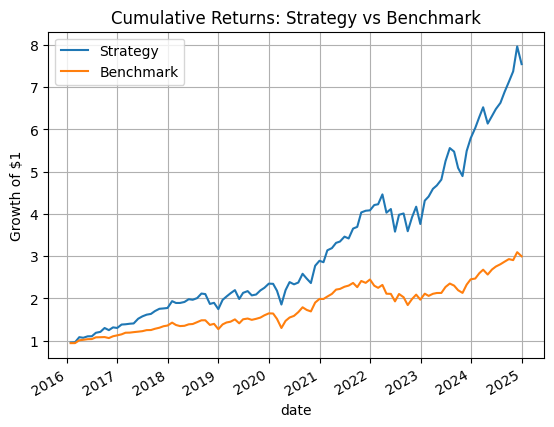

In [186]:
# 4. One-tailed t-test: is strategy > benchmark?
excess_returns = returns_df['Strategy'] - returns_df['Benchmark']
t_stat, p_two_tailed = stats.ttest_1samp(excess_returns, 0)
p_one_tailed = p_two_tailed / 2 if t_stat > 0 else 1.0

print(f"\nT-statistic: {t_stat:.3f}")
print(f"One-tailed p-value: {p_one_tailed:.3f}")
if p_one_tailed < 0.05:
    print("✅ Strategy significantly outperforms benchmark (reject H₀)")
else:
    print("❌ No significant outperformance (fail to reject H₀)")

# 5. Cumulative return plot
plt.figure(figsize=(10, 5))
(returns_df + 1).cumprod().plot()
plt.title("Cumulative Returns: Strategy vs Benchmark")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()